# ¿Y si lograr emisiones cero no basta?

14 modelos climáticos. Una pregunta incómoda. Después de lograr emisiones netas cero, la temperatura de la superficie baja... pero en **12 de 14 simulaciones**, vuelve a subir. El océano profundo devuelve el calor que absorbió durante décadas.

> **Paper:** *"Deep ocean control of global temperature after net-zero emissions"*
> — Lee et al. (Nature Geoscience, 2026)
> DOI: [10.1038/s41561-026-01934-1](https://doi.org/10.1038/s41561-026-01934-1)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-21-oceano-profundo-emisiones-cero/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/watch?v=dVfrDJzvF_Y)

## El escenario más optimista del planeta

El escenario **SSP1-2.6** asume lo mejor: transición energética rápida, captura de carbono, emisiones netas cero alrededor de 2050. El CO₂ atmosférico toca techo en ~443 ppm y empieza a bajar.

Bajo esas condiciones, la temperatura de la superficie baja. Misión cumplida... ¿no?

Este equipo corrió 14 modelos CMIP6 (los que usa el IPCC) durante 300 años — hasta el 2299 — para ver qué pasa **después** de que la temperatura empieza a bajar. Y usaron un modelo de balance de energía de dos capas para entender el mecanismo.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
YEAR_NETZERO = 2050          # Año aprox. de emisiones netas cero (SSP1-2.6)
YEAR_END = 2299              # Año final de las simulaciones
FUENTE = 'Fuente: Lee et al. (2026), Nature Geoscience | Datos: Zenodo (CC-BY-4.0)'

COLOR_SURFACE = '#DC2626'    # Rojo — temperatura de superficie
COLOR_DEEP = '#2563EB'       # Azul — océano profundo
COLOR_CO2 = '#059669'        # Verde — CO₂
COLOR_REF = '#D97706'        # Amber — referencia
COLOR_MODELS = '#BBBBBB'     # Gris — modelos individuales
COLOR_REBOUND = '#7C3AED'    # Violeta — rebound

# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
cmip_surf = pd.read_csv('datos/cmip_temperatura_superficie.csv')
cmip_deep = pd.read_csv('datos/cmip_temperatura_oceano_profundo.csv')
ebm = pd.read_csv('datos/ebm_temperatura_por_gamma.csv')
co2 = pd.read_csv('datos/co2_rcp26.csv')
rebound = pd.read_csv('datos/cmip_rebound_resumen.csv')

print(f"✅ {cmip_surf['model'].nunique()} modelos CMIP6 | {cmip_surf['year'].min()}-{cmip_surf['year'].max()}")
print(f"✅ CO₂ SSP1-2.6: pico {co2['co2_ppm'].max():.0f} ppm → {co2['co2_ppm'].iloc[-1]:.0f} ppm")
print(f"✅ {rebound['has_rebound'].sum()}/{len(rebound)} modelos con rebound de temperatura")

✅ 14 modelos CMIP6 | 2000-2299
✅ CO₂ SSP1-2.6: pico 443 ppm → 361 ppm
✅ 12/14 modelos con rebound de temperatura


## Las trayectorias de 300 años

Aquí está.

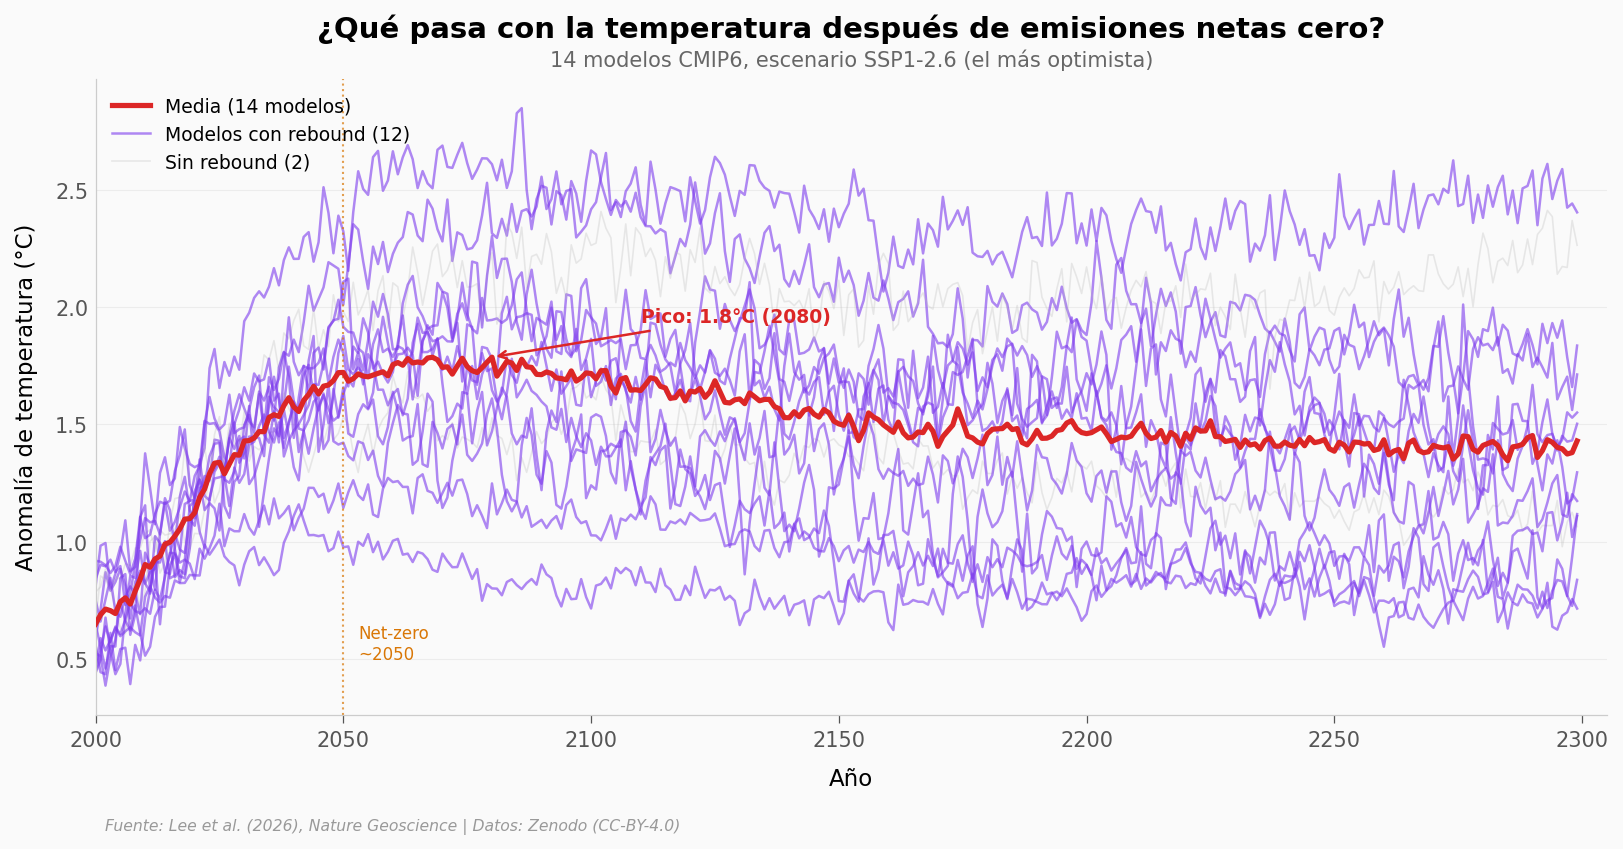

In [2]:
# Gráfica hero: 14 modelos CMIP — temperatura de superficie vs CO₂
fig, ax1 = plt.subplots(figsize=(13, 5.5))

# Plot each model
for m in range(14):
    sub = cmip_surf[cmip_surf['model'] == m]
    has_reb = rebound.loc[rebound['model'] == m, 'has_rebound'].values[0]
    color = COLOR_REBOUND if has_reb else COLOR_MODELS
    alpha = 0.6 if has_reb else 0.3
    lw = 1.2 if has_reb else 0.8
    ax1.plot(sub['year'], sub['temp_anomaly_C'], color=color, alpha=alpha, linewidth=lw)

# Ensemble mean
mean_by_year = cmip_surf.groupby('year')['temp_anomaly_C'].mean()
ax1.plot(mean_by_year.index, mean_by_year.values, color=COLOR_SURFACE,
         linewidth=2.5, label='Media de 14 modelos', zorder=6)

# Net-zero line
ax1.axvline(x=YEAR_NETZERO, color=COLOR_REF, linewidth=1, linestyle=':', alpha=0.7)
ax1.text(YEAR_NETZERO + 3, 0.5, 'Net-zero\n~2050', fontsize=8, color=COLOR_REF)

# Annotations
peak_year = int(mean_by_year.idxmax())
peak_val = mean_by_year.max()
ax1.annotate(f'Pico: {peak_val:.1f}°C ({peak_year})',
             xy=(peak_year, peak_val), xytext=(peak_year + 30, peak_val + 0.15),
             fontsize=9, color=COLOR_SURFACE, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=COLOR_SURFACE, lw=1.2))

ax1.set_xlabel('Año', fontsize=11)
ax1.set_ylabel('Anomalía de temperatura (°C)', fontsize=11)
ax1.set_title('¿Qué pasa con la temperatura después de emisiones netas cero?',
             fontsize=14, fontweight='bold', pad=20)
ax1.text(0.5, 1.02, '14 modelos CMIP6, escenario SSP1-2.6 (el más optimista)',
        transform=ax1.transAxes, fontsize=10, color='#666666', ha='center')
ax1.set_xlim(2000, 2305)

# Legend
from matplotlib.lines import Line2D
legend_items = [
    Line2D([0], [0], color=COLOR_SURFACE, linewidth=2.5, label='Media (14 modelos)'),
    Line2D([0], [0], color=COLOR_REBOUND, linewidth=1.2, alpha=0.6, label='Modelos con rebound (12)'),
    Line2D([0], [0], color=COLOR_MODELS, linewidth=0.8, alpha=0.3, label='Sin rebound (2)'),
]
ax1.legend(handles=legend_items, loc='upper left', fontsize=9, framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/trayectorias_cmip.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que vemos

Las líneas violeta son los 12 modelos que muestran **rebound** — la temperatura baja después de net-zero, pero luego vuelve a subir. La línea roja es la media de los 14 modelos.

El pico de temperatura ocurre alrededor de 2080 (media), pero la trayectoria no es una bajada limpia. Después de un mínimo (~2285), la media empieza a remontar. En los modelos individuales, el rebound promedio es de **+0.26°C** — no es catastrófico, pero es una fracción que *no estaba en el presupuesto*.

Dos modelos (gris) no muestran rebound dentro del horizonte de 300 años. Podría ser que necesitan más tiempo.

## El mecanismo: superficie vs océano profundo

¿Por qué rebota la temperatura? La clave está en lo que pasa **debajo** de la superficie.

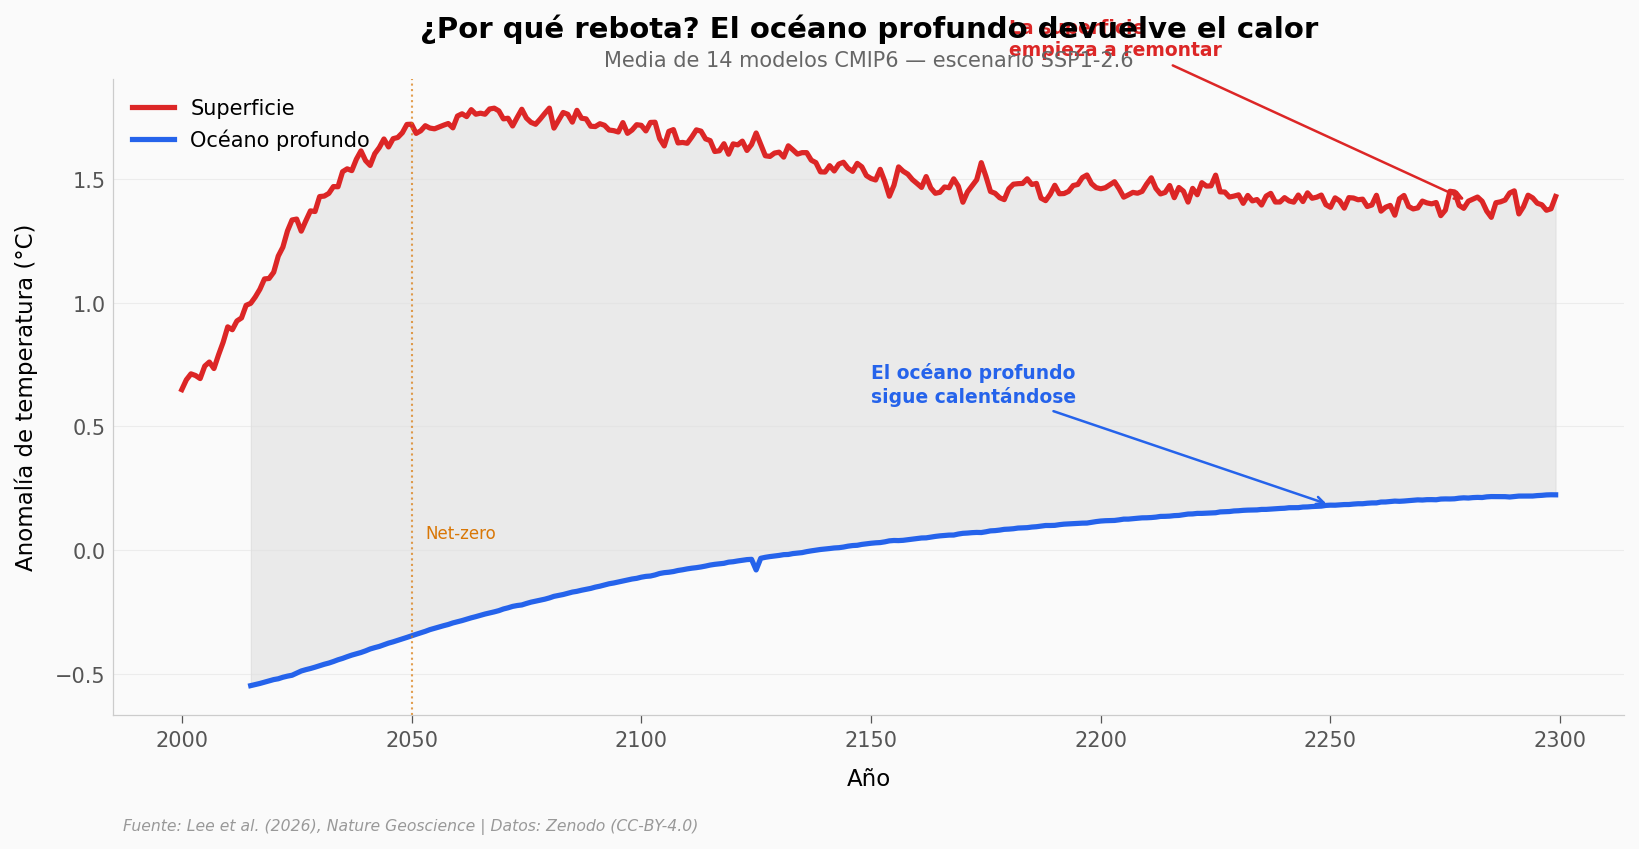

In [3]:
# Superficie vs océano profundo — media de 14 modelos
fig, ax = plt.subplots(figsize=(13, 5.5))

# Surface mean
surf_mean = cmip_surf.groupby('year')['temp_anomaly_C'].mean()
ax.plot(surf_mean.index, surf_mean.values, color=COLOR_SURFACE,
        linewidth=2.5, label='Superficie')

# Deep ocean mean (starts at 2015)
deep_mean = cmip_deep.groupby('year')['deep_ocean_anomaly_C'].mean()
ax.plot(deep_mean.index, deep_mean.values, color=COLOR_DEEP,
        linewidth=2.5, label='Océano profundo')

# Fill the gap
common_years = sorted(set(surf_mean.index) & set(deep_mean.index))
surf_vals = [surf_mean[y] for y in common_years]
deep_vals = [deep_mean[y] for y in common_years]
ax.fill_between(common_years, surf_vals, deep_vals, alpha=0.1, color='#666666')

# Annotate the convergence
ax.annotate('El océano profundo\nsigue calentándose',
            xy=(2250, deep_mean.loc[2250] if 2250 in deep_mean.index else 0.2),
            xytext=(2150, 0.6),
            fontsize=9, color=COLOR_DEEP, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_DEEP, lw=1.2))

ax.annotate('La superficie\nempieza a remontar',
            xy=(2280, surf_mean.loc[2280] if 2280 in surf_mean.index else 1.4),
            xytext=(2180, 2.0),
            fontsize=9, color=COLOR_SURFACE, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_SURFACE, lw=1.2))

ax.axvline(x=YEAR_NETZERO, color=COLOR_REF, linewidth=1, linestyle=':', alpha=0.7)
ax.text(YEAR_NETZERO + 3, 0.05, 'Net-zero', fontsize=8, color=COLOR_REF)

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Anomalía de temperatura (°C)', fontsize=11)
ax.set_title('¿Por qué rebota? El océano profundo devuelve el calor',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Media de 14 modelos CMIP6 — escenario SSP1-2.6',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/superficie_vs_profundo.png', dpi=200, bbox_inches='tight')
plt.show()

### El efecto tijera

Mientras la superficie se enfría (línea roja baja), el océano profundo **sigue calentándose** (línea azul sube). Décadas de calor acumulado se difunden lentamente hacia abajo.

Cuando la diferencia de temperatura entre superficie y fondo se reduce lo suficiente, el océano profundo deja de absorber calor y empieza a **liberarlo** hacia la superficie. Una bañera de agua caliente con la ventana abierta: el aire se enfría primero, pero el agua sigue irradiando calor durante horas.

El modelo de balance de energía (EBM) usa un parámetro clave: γ (gamma) — el acoplamiento entre superficie y océano profundo. Veamos qué pasa cuando lo variamos.

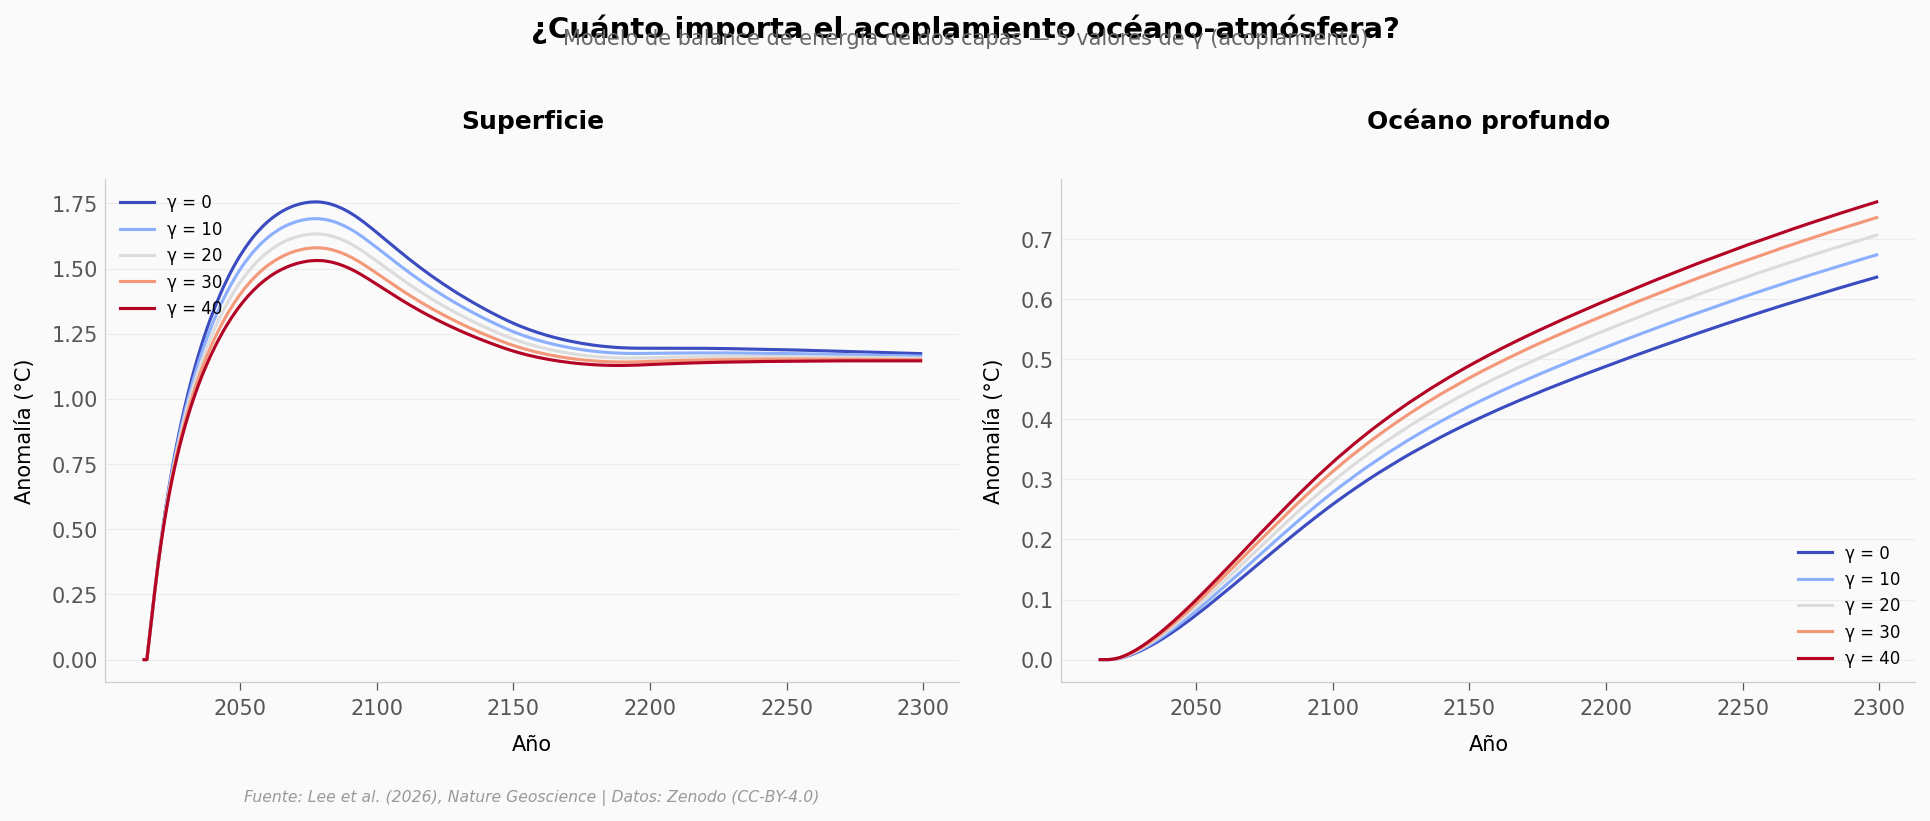

In [4]:
# EBM: sensibilidad al acoplamiento océano-superficie (gamma)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

gammas = [0, 10, 20, 30, 40]
cmap = plt.cm.coolwarm
colors_g = [cmap(g / 40) for g in gammas]

for g, color in zip(gammas, colors_g):
    sub = ebm[ebm['gamma'] == g]
    ax1.plot(sub['year'], sub['surface_temp_C'], color=color, linewidth=1.5,
             label=f'γ = {g}')
    ax2.plot(sub['year'], sub['deep_ocean_temp_C'], color=color, linewidth=1.5,
             label=f'γ = {g}')

ax1.set_title('Superficie', fontsize=12, fontweight='bold')
ax1.set_xlabel('Año', fontsize=10)
ax1.set_ylabel('Anomalía (°C)', fontsize=10)
ax1.legend(fontsize=8, loc='upper left', framealpha=0.9)

ax2.set_title('Océano profundo', fontsize=12, fontweight='bold')
ax2.set_xlabel('Año', fontsize=10)
ax2.set_ylabel('Anomalía (°C)', fontsize=10)
ax2.legend(fontsize=8, loc='lower right', framealpha=0.9)

fig.suptitle('¿Cuánto importa el acoplamiento océano-atmósfera?',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, 0.98, 'Modelo de balance de energía de dos capas — 5 valores de γ (acoplamiento)',
         fontsize=10, color='#666666', ha='center')
plt.tight_layout()
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ebm_sensibilidad.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que dice el EBM

A mayor γ (más acoplamiento), la superficie se calienta menos al principio (el océano absorbe más), pero el océano profundo se calienta más a largo plazo. Con γ alto, el rebound aparece — la superficie toca fondo y remonta.

Es una trampa térmica: cuanto más eficiente es el océano absorbiendo calor hoy, más calor devolverá mañana.

## ¿Cuánto remontan los modelos? La distribución del rebound.

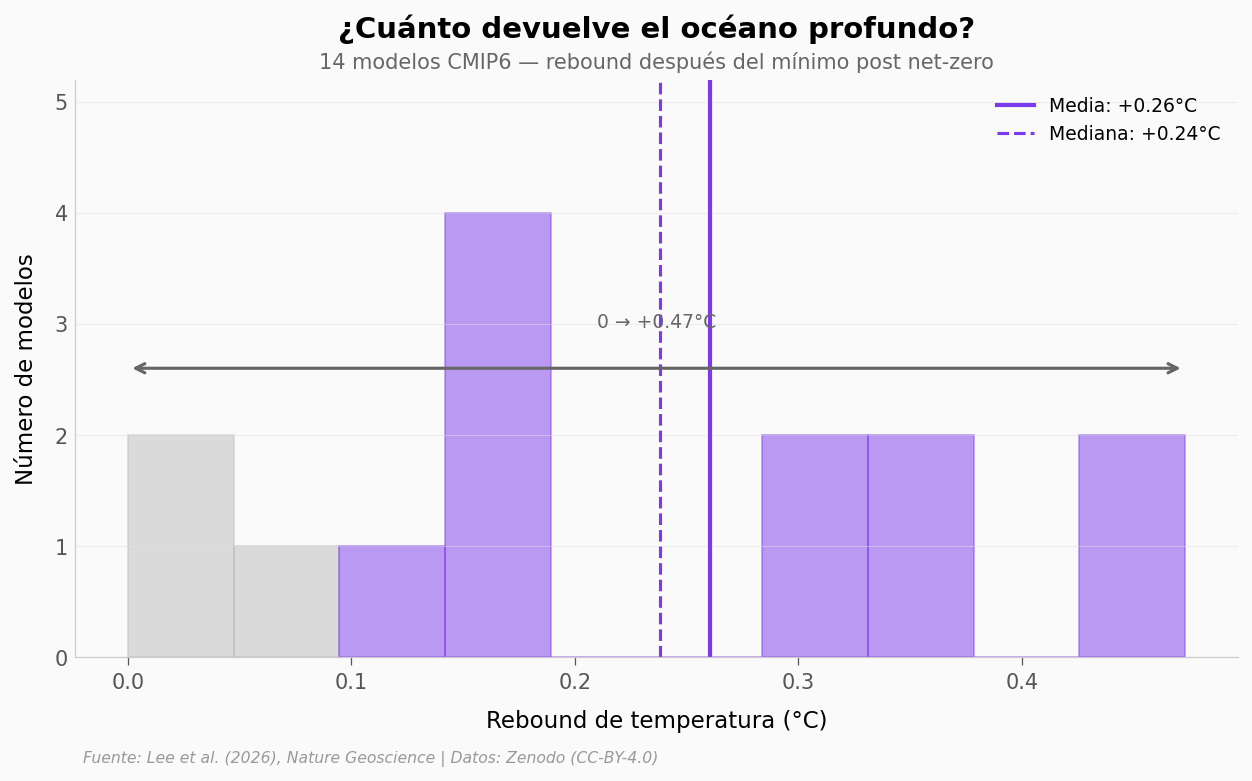

Modelos con rebound: 12/14
Rebound medio (modelos con rebound): +0.261°C
Rebound mediano: +0.238°C
Rebound máximo: +0.473°C (modelo 12)


In [5]:
# Distribución del rebound entre los 14 modelos CMIP6
fig, ax = plt.subplots(figsize=(10, 5))

# All 14 models
vals = rebound['rebound_C'].values
n, bins, patches = ax.hist(vals, bins=10, color=COLOR_REBOUND, alpha=0.5,
                           edgecolor=COLOR_REBOUND, linewidth=0.8)

# Color the zero-rebound bins differently
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge < 0.05:
        patch.set_facecolor(COLOR_MODELS)
        patch.set_edgecolor(COLOR_MODELS)
        patch.set_alpha(0.5)

y_max = max(n) * 1.3
ax.set_ylim(0, y_max)

# Mean and median lines
mean_reb = rebound[rebound['has_rebound']]['rebound_C'].mean()
median_reb = rebound[rebound['has_rebound']]['rebound_C'].median()
ax.axvline(x=mean_reb, color=COLOR_REBOUND, linewidth=2, label=f'Media: +{mean_reb:.2f}°C')
ax.axvline(x=median_reb, color=COLOR_REBOUND, linewidth=1.5, linestyle='--',
           label=f'Mediana: +{median_reb:.2f}°C')

# Arrow
ax.annotate('', xy=(vals.max(), y_max * 0.5), xytext=(0, y_max * 0.5),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(vals.max() / 2, y_max * 0.57, f'0 → +{vals.max():.2f}°C',
        fontsize=9, color='#666666', ha='center')

ax.set_xlabel('Rebound de temperatura (°C)', fontsize=11)
ax.set_ylabel('Número de modelos', fontsize=11)
ax.set_title('¿Cuánto devuelve el océano profundo?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, '14 modelos CMIP6 — rebound después del mínimo post net-zero',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_rebound.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Modelos con rebound: {rebound['has_rebound'].sum()}/{len(rebound)}")
print(f"Rebound medio (modelos con rebound): +{mean_reb:.3f}°C")
print(f"Rebound mediano: +{median_reb:.3f}°C")
print(f"Rebound máximo: +{vals.max():.3f}°C (modelo {rebound.loc[rebound['rebound_C'].idxmax(), 'model']})")

## Lo que los datos soportan

| Afirmación del paper | ¿Soportada? | Detalle |
|---|---|---|
| La temperatura de superficie baja al reducir CO₂ | ✅ | Los 14 modelos muestran declive desde el pico (~2080) |
| La tendencia de enfriamiento podría revertirse | ✅ | 12/14 modelos (86%) muestran rebound. El paper usa "could" — lenguaje condicional |
| El océano profundo devuelve calor | ✅ | La anomalía del océano profundo sigue subiendo mientras la superficie baja |
| El acoplamiento océano-superficie (γ) controla el rebound | ✅ | EBM reproduce la dirección: solo γ alto genera rebound. La magnitud EBM (~0.02°C) es menor que CMIP (~0.26°C) — esperado por la simplificación del modelo de 2 capas |
| Emisiones netas cero → temperatura estable | ⚠️ | No del todo — los modelos proyectan que la temperatura no se estabiliza en 300 años. Baja, pero luego remonta. El "cero neto" no es punto final |

> **Limitaciones:** (1) Son **simulaciones**, no observaciones. Los modelos CMIP6 tienen incertidumbres en cómo representan el océano (la parametrización oceánica varía entre modelos). (2) El EBM de dos capas simplifica la física real — la difusión vertical en el océano no es uniforme. (3) Solo se usa el escenario SSP1-2.6 (el más optimista); con escenarios de mayor emisión, los efectos podrían ser más pronunciados. (4) El horizonte de 300 años (2000-2299) podría no ser suficiente para ver el rebound completo en todos los modelos.

> **Nota sobre certeza:** El paper usa "could" y "would" — lenguaje condicional. Los modelos *proyectan* el rebound, no lo *demuestran*. Es un mecanismo físicamente plausible que las simulaciones soportan, no un hecho observado.

## Ahora tú

1. **¿Qué modelo tiene el rebound más tardío?** Usa `cmip_rebound_resumen.csv` para ver en qué año cada modelo toca su mínimo. ¿Los que tardan más en tocar fondo tienen un rebound mayor?

2. **¿Hay correlación entre el pico de temperatura y el rebound?** Compara `peak_temp_C` con `rebound_C` en el CSV de resumen. ¿Los modelos más calientes rebotan más?

3. **Prueba cambiar γ = 40 en el EBM.** ¿A partir de qué valor de γ aparece el rebound? El CSV tiene γ = 0, 10, 20, 30, 40.

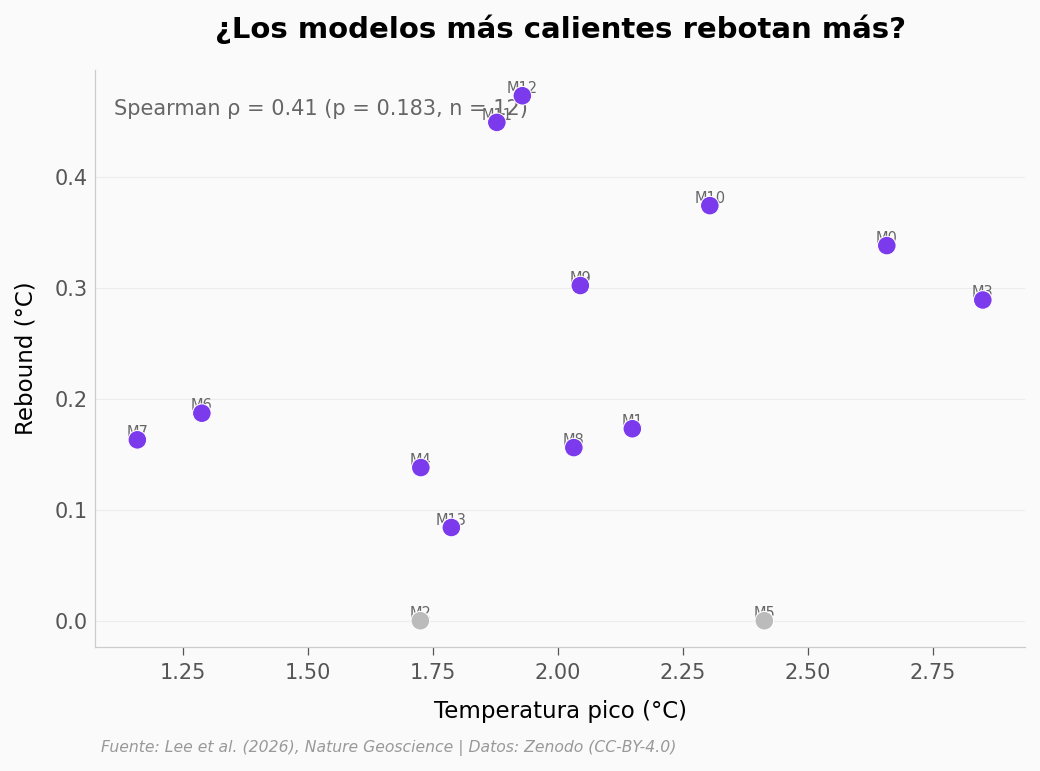

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Hay correlación entre temperatura pico y magnitud del rebound?
from scipy import stats

rebounders = rebound[rebound['has_rebound']]
rho, p = stats.spearmanr(rebounders['peak_temp_C'], rebounders['rebound_C'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(rebound['peak_temp_C'], rebound['rebound_C'],
           c=[COLOR_REBOUND if r else COLOR_MODELS for r in rebound['has_rebound']],
           s=80, edgecolors='white', linewidths=0.5, zorder=5)

for _, row in rebound.iterrows():
    ax.annotate(f"M{int(row['model'])}", (row['peak_temp_C'], row['rebound_C']),
                fontsize=7, ha='center', va='bottom', color='#666666')

ax.set_xlabel('Temperatura pico (°C)', fontsize=11)
ax.set_ylabel('Rebound (°C)', fontsize=11)
ax.set_title('¿Los modelos más calientes rebotan más?',
             fontsize=14, fontweight='bold', pad=15)
ax.text(0.02, 0.95, f'Spearman ρ = {rho:.2f} (p = {p:.3f}, n = {len(rebounders)})',
        transform=ax.transAxes, fontsize=10, color='#666666', va='top')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/correlacion_pico_rebound.png', dpi=200, bbox_inches='tight')
plt.show()

---

## Créditos

- **Paper:** Lee et al. (2026). *"Deep ocean control of global temperature after net-zero emissions."* Nature Geoscience. DOI: [10.1038/s41561-026-01934-1](https://doi.org/10.1038/s41561-026-01934-1)
- **Datos:** [Zenodo — Lee et al.](https://zenodo.org/records/18203190) (CC-BY-4.0)
- **Código original:** Scripts NCL del paper. Adaptado a Python para este notebook.
- **Código:** [GitHub — Ciencia a Mordiscos / El Lab](https://github.com/Ciencia-a-Mordiscos/lab)
- **Licencia:** CC-BY-4.0